# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Rivera, Kyle Florian
- _Student No._: 2024-16197
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Figure 1: Square root subtractive cancellation](Figures/sqrt_func.png)

Figure 1: Catastrophic cancellation of a function $ f(x) = \sqrt{x^2 + x} - x $ for $x \gg 1$

The figure shows the catastrophic cancellation of a function under various data types, namely 16 to 128-bit floating point precisions. Specifically, the catastrophic cancellation for similarly large values are shown, with `float64` deviating from the expected value of $0.5$ after reaching values greater than $10^{14}$. Meanwhile, tweaking the function in order to avoid subtraction of two similarly large values, it was shown that the function maintains its expected value, even for $x \gg 1$, as long as overflow is not reached for the specific data type.

![Figure 2: Exponential catastrophic cancellation](Figures/exp_func.png)

Figure 2: Catastrophic cancellation of a function $ f(x) = \frac{e^x - 1}{x} $ for $0 < x \ll 1$

On the other hand, the catastrophic cancellation for similarly small values are shown, with `float64` deviating from the expected value of $1.0$ after reaching values less than $10^-{14}$. Tweaking the function in order to alleviate errors of subtracting two nearly equal values ($e^x$ and $1$), it was shown that the function maintains its expected value, even for $x \ll 1$, as long as overflow is not reached for the specific data type.

### Report discussion

1. Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?

    Since the numbers we are dealing with are very large, taking the difference between the two causes error to blow up instead of (relatively) preserving it.
    - The good: The formula for the good root intentionally avoids complications with `floats` by avoiding subtraction of enormously large (or small) numbers. Since the datatypes that we are dealing are `floats`, we make sure to utilize its strengths by preferring to multiply (or divide) as floating points simply utilize exponents when doing such operations. We do this by using Vieta's formulas (or simply product of roots) to calculate the second root through division.
    - The bad: Catastrophic cancellation occurs when subtracting large (or very small) precise almost equal numbers as floating point precision falters. As such, the errors observed in these calculations are bloated.
    
2. In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied?
    - For the first function (square root), catastrophic cancellation occurs when $x \gg 1$. In a standard `float64` datatype, the result deviates from the expected value of $0.5$ into $0.625$, $1.0$, $2.0$, and $0.0$ (especially for values $>10^{16}$). To remedy the catastrophic cancellations, the function was rationalized in order to remove dependencies on the subtraction operator.
    - Meanwhile, the second function (exponential) showed that catastrophic cancellation occured for $0 < x \ll 1$. Similar to the previous question, the result deviates from the expected value of $1.0$ (for values $<10^{-14}$, varying from $0.5$ to $2.0$. To remedy the catastrophic cancellation, the denominator was transformed into an alternative form $ln(...)$, which in of itself introduces errors. This way, the errors in the numerator is cancelled by the errors in the denominator. Alternatively, we can implement NumPy's special function which handles the errors for us.
   
### Other comments
- Aside from the time constraint, this was somewhat fun and straightforward.

## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
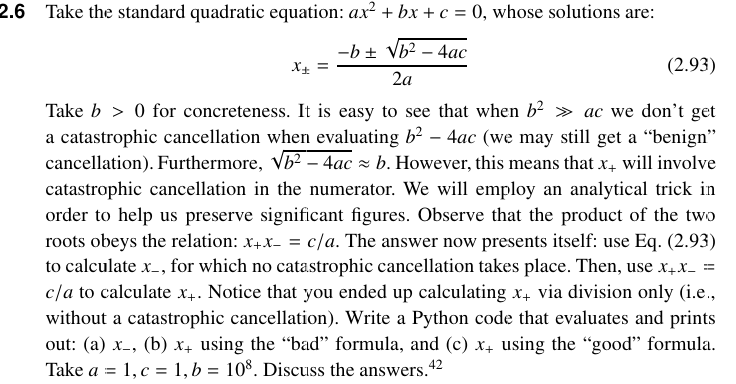

In [2]:
def calculate_disc(a, b, c): # calculate discriminant for brevity)
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return False
    return discriminant

def minus_root(a, b, c):
    disc_sqr = m.sqrt(calculate_disc(a, b, c))
    m_root = -(b + disc_sqr) / (2*a)
    return m_root

def bad_plus_root(a, b, c): 
    disc_sqr = m.sqrt(calculate_disc(a, b, c))
    bad_p_root = -(b - disc_sqr) / (2*a)
    return bad_p_root

def good_plus_root(a, b, c): # calculating positive root using product of roots formula
    good_p_root = c / (a*minus_root(a, b, c))
    return good_p_root

In [3]:
# initialize variables
a = 1
b = 1e8 # 10^8
c = 1

# calculates good root, bad root, etc.
if calculate_disc(a, b, c) != False:
    item_1 = minus_root(a, b, c)
    item_2 = bad_plus_root(a, b, c)
    item_3 = good_plus_root(a, b, c)
    difference = abs(item_2 - item_3)
    err = abs(difference / item_3) # we take the error relative to the good root (the one which avoided catastrophic cancellation)
    print(f"minus root: {item_1}\nbad plus root: {item_2}\ngood plus root: {item_3}\n\ndifference (plusroot): {difference}\nerror (rel. to good root): {err*100}%")
else:
    print("No real solutions.")

minus root: -100000000.0
bad plus root: -7.450580596923828e-09
good plus root: -1e-08

difference (plusroot): 2.549419403076172e-09
error (rel. to good root): 25.49419403076172%


Discuss: 

Calculating the positive root the bad way results in the term $\sqrt{10^{16} - 4}$ being subtracted from $10^8$. Doing this forces the subtraction of nearly equal values, cancelling out significant digits as normal `float64` cannot maintain the precision required. As a result, the remaining trailing digits' error propagates, producing an error of about $25.5\%$, which can be seen above.

Doing the calculation in a good way, we avoid such arithmetic and go straight to floating-point division. Since we are dealing with floats, calculating $\frac{1}{-10^{8}}$ is relatively light work, as we are operating directly on exponents while preserving all significant digits.

#### Problem 1 code summary

The following code calculates the roots of a quadratic equation while avoiding consequences of catastrophic cancellation for large coefficients. The minus root $x_-$ was calculated while the plus root $x_+$ was computed using two different approaches, direct substitution via the quadratic formula and by utilizing the product of roots property. The code was wrote in accordance to the instructions, with an additional error calculation relative to the "`good_plus_root`", in order to further illustrate the error caused by catastrophic cancellation.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur?
    - Catastrophic cancellation occurs when $x \gg 1$ since as $x$ grows large, $\sqrt{x^2 + x} \approx x$. Subtraction of identically large numbers results to catastrophic cancellation
      
- How can we rewrite the function to avoid catastrophic cancellation?
    - We can multiply by the conjugate in order to remove the subtraction operation:
      $$\begin{align}
      f(x) = \sqrt{x^2 + x} - x = (\sqrt{x^2 + x} - x) \left(\frac{\sqrt{x^2 + x} + x}{\sqrt{x^2 + x} + x} \right) = \frac{x}{\sqrt{x^2 + x} + x} 
      \end{align}
      $$

- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [4]:
def f(x):
    return np.sqrt(x*x + x) - x

def better_f(x):
    return x / (np.sqrt(x*x + x) + x)

x_s = np.logspace(0, 30, 50000)
x_16 = np.float16(x_s)
x_32 = np.float32(x_s)
x_64 = x_s
x_128 = np.float128(x_s)

y_1 = f(x_s)
y_2 = better_f(x_s)

/tmp/ipykernel_139282/722757153.py:8: RuntimeWarning: overflow encountered in cast
  x_16 = np.float16(x_s)


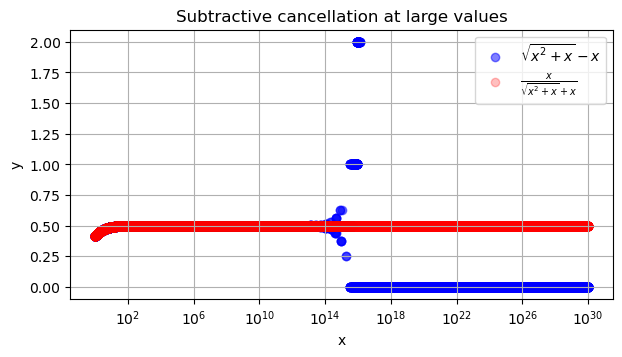

In [5]:
fig, ax = plt.subplots(figsize = (7, 3.5))

plt.title("Subtractive cancellation at large values")
ax.scatter(x_s, y_1, color = "blue", label = r"$\sqrt{x^2 + x} - x$", alpha = 0.5)
ax.scatter(x_s, y_2, color = "red", label = r"$\frac{x}{\sqrt{x^2 + x} + x}$", alpha = 0.25)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.legend()
ax.grid("True")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("tight")

plt.show()

For `float64`, we find the original function to encounter catastrophic cancellation at $x \approx 10^{14}$. Subtraction of identically large numbers can cause floating point errors. We can see here that the value jumps in discrete values of $2^n$, e.g. $0.75, 1.00, 2.00$. For $x > 10^{15}$, we can see that the value drops down to zero as the computer can't compute precise enough values, eventually approximating $x^2 + x \approx x^2$.

/tmp/ipykernel_139282/722757153.py:2: RuntimeWarning: overflow encountered in multiply
  return np.sqrt(x*x + x) - x
/tmp/ipykernel_139282/722757153.py:2: RuntimeWarning: overflow encountered in add
  return np.sqrt(x*x + x) - x
/tmp/ipykernel_139282/722757153.py:2: RuntimeWarning: invalid value encountered in subtract
  return np.sqrt(x*x + x) - x
/tmp/ipykernel_139282/722757153.py:5: RuntimeWarning: overflow encountered in multiply
  return x / (np.sqrt(x*x + x) + x)
/tmp/ipykernel_139282/722757153.py:5: RuntimeWarning: overflow encountered in add
  return x / (np.sqrt(x*x + x) + x)
/tmp/ipykernel_139282/722757153.py:5: RuntimeWarning: invalid value encountered in divide
  return x / (np.sqrt(x*x + x) + x)


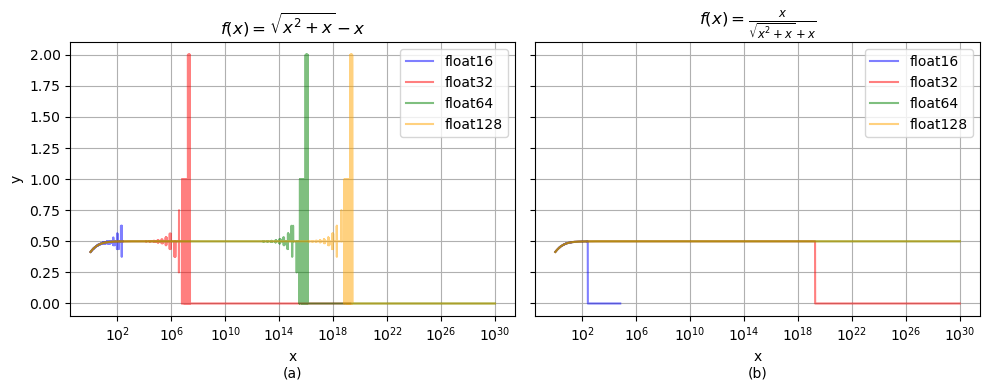

In [7]:
x_values = [x_16, x_32, x_64, x_128] # we put logspace to list

fig, axs = plt.subplots(1, 2, figsize = (10, 4), sharey = True)

# plot settings
color_list = ["blue", "red", "green", "orange"]
labels = ["float16", "float32", "float64", "float128"]
plots_config = [
    (axs[0], f, r"$f(x) = \sqrt{x^2 + x} - x$"),
    (axs[1], better_f, r"$f(x) = \frac{x}{\sqrt{x^2 + x} + x}$")
    ]

# we iterate through 4 data types across two functions
for ax, func, title in plots_config:
    for x, color, label in zip(x_values, color_list, labels): # we just zip to avoid using even more for loops...
        y = func(x)
        ax.plot(x, y, color = color, label = label, alpha = 0.5)
    ax.set_xscale("log")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

axs[0].set_ylabel("y")
axs[0].set_xlabel("x\n(a)")
axs[1].set_xlabel("x\n(b)")

plt.tight_layout()
plt.savefig("Figures/sqrt_func.png")
plt.show()

We encounter lots of `RuntimeWarning` here due to the lack of precision of our floats. Similar to the previous graph, we find higher floats to have higher "tolerance" and only exhibit catastrophic cancellation at higher values. We list it as follows for the original function $f(x)$
| Precision | Threshold |
| -------- | -------- |
| `float16` | $10^{2}$ |
| `float32` | $10^{6}$ |
| `float64` | $10^{14}$ |
| `float128` | $10^{18}$ |

For the transformed function (b), we can see that catastrophic cancellation disappears at higher $x$ values. One thing of note however is that overflow is still observed, especially for low precision data types (`float16`, `float32`)

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur?
    - Catastrophic cancellation occurs when $0< x \ll 1$. As $x$ approaches $0$, $e^x \approx 1$, causing the numerator to subtract nearly equal numbers and lose significant digits.
- How can we resolve the catastrophic cancellation?
    - We can transform the denominator and get the following:
      $$
        g(x) = \frac{e^x - 1}{x} =  \frac{e^x - 1}{\ln(e^x)}
      $$
      This is resolved by introducing another rounding error at the denominator caused by $\ln(...)$. The error caused by the numerator is (in a sense) subsequently cancelled by the error from the denominator.
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [ ]:
def g(x):
    return (np.exp(x) - 1) / x

def better_g(x):
    return (np.exp(x) - 1) / (np.log(np.exp(x)))

def special_g(x):
    return np.expm1(x)/x

# we do a similar initialization like the previous problem
x_s = np.logspace(-20, 0, 1000)
x_16 = np.float16(x_s)
x_32 = np.float32(x_s)
x_64 = x_s
x_128 = np.float128(x_s)

y_1 = g(x_s)
y_2 = better_g(x_s)
y_3 = np.expm1(x_s) / x_s # the numpy special function in the instruction

In [ ]:
fig, ax = plt.subplots(figsize = (6, 4.5))

plt.title("Subtractive cancellation at small values")
ax.scatter(x_s, y_1, color = "blue", label = r"$\frac{e^x - 1}{x}$", alpha = 0.4)
ax.scatter(x_s, y_2, color = "red", label = r"$\frac{e^x - 1}{\ln(e^x)}$", alpha = 0.2)
ax.scatter(x_s, y_3, color = "orange", label = "expm1", alpha = 0.1)
ax.set_xscale("log")
ax.legend(loc = "lower right")
ax.grid("True")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("tight")
plt.show()

For the original function, we find catastrophic cancellation to occur at $x \approx 10^{-14}$, with the function dropping to zero for values closer and closer to zero. Meanwhile, the modified function and the NumPy special function correctly evaluates the value even at more and more precise values $x \ll 1$.

In [ ]:
x_values = [x_16, x_32, x_64, x_128] # we put logspace to list

fig, axs = plt.subplots(1, 3, figsize = (15, 5), sharey = True)

# plot settings
color_list = ["blue", "red", "green", "orange"]
labels = ["float16", "float32", "float64", "float128"]
plots_config = [
    (axs[0], g, r"$g(x) = \frac{e^x - 1}{x}$"),
    (axs[1], better_g, r"$g(x) = \frac{e^x - 1}{\ln(e^x)}$"),
    (axs[2], special_g, "$g(x) = $expm1")
    ]

# we iterate through 4 data types across two functions
for ax, func, title in plots_config:
    for x, color, label in zip(x_values, color_list, labels): # we just zip to avoid using even more for loops...
        y = func(x)
        ax.scatter(x, y, color = color, s = 40, label = label, alpha = 0.25)
    ax.set_xscale("log")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(loc="lower right")

axs[0].set_ylabel("y")
axs[0].set_xlabel("x\n(a)")
axs[1].set_xlabel("x\n(b)")
axs[2].set_xlabel("x\n(c)")

plt.tight_layout()
plt.savefig("Figures/exp_func.png")
plt.show()

Similar to the previous function, we find higher floats to have higher "tolerance" and only exhibit catastrophic cancellation at more and more precise values $(0< x \ll 1)$. We list the threshold as follows for the original function $f(x)$
| Precision | Threshold |
| -------- | -------- |
| `float16` | $10^{-2}$ |
| `float32` | $10^{-6}$ |
| `float64` | $10^{-14}$ |
| `float128` | $10^{-18}$ |

In a similar fashion, breakdown occurs for same amount of exponent (but negative sign). For the transformed function (b) and special function (c), we can see that catastrophic cancellation disappears at more precise $x$ values. 

#### Problem 2 code summary

The code above aims to visualize catastrophic cancellation for both very very large and very very small precise numbers. For both functions, we transform it in such a way to avoid the effects of catastrophic cancellation in very very large (or small) values. In order to properly visualize precision errors, we overlay various datatypes (`float`, `double`, etc.) in a graph. To compare the effect of function transformation to avoid catastrophic cancellation, we used the standard `float64`.

---